# Data Exploration

In this notebook, we will load the housing dataset and explore it before building a model.

The goal is to understand what columns are available, check whether any values are missing, and look at simple relationships between house features and price.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

# This makes plots appear inside the notebook.
%matplotlib inline

In [2]:
# Load the dataset directly from a public CSV URL.
housing_data = pd.read_csv(DATA_URL)

# Display the first few rows so we can see what the data looks like.
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Basic dataset checks

These checks help us understand the size and structure of the dataset.

In [3]:
# Number of rows and columns.
housing_data.shape

(20640, 10)

In [4]:
# Column names.
housing_data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [5]:
# Data types and non-missing values for each column.
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Missing values

Missing values are blank or unavailable values. Many machine learning models cannot use them directly, so we need to know where they are.

In [6]:
housing_data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Summary statistics

Summary statistics show the typical range of the numeric columns.

In [7]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Distribution of house prices

The target column is `median_house_value`, which we will try to predict later.

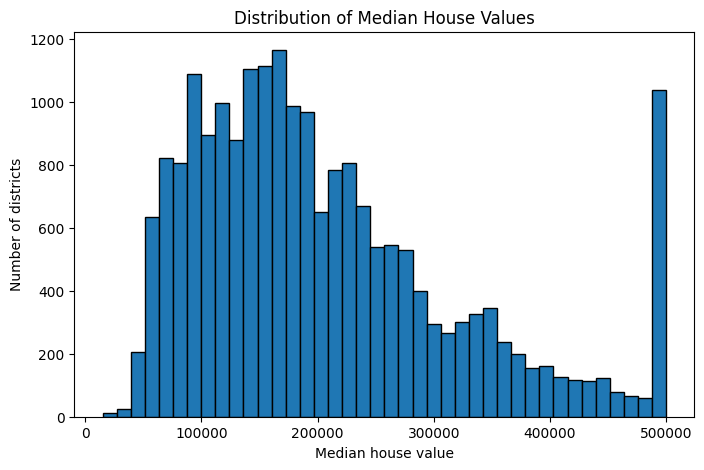

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(housing_data["median_house_value"], bins=40, edgecolor="black")
plt.title("Distribution of Median House Values")
plt.xlabel("Median house value")
plt.ylabel("Number of districts")
plt.show()

## House size and price

This dataset does not contain exact square footage. We will use `total_rooms` as a simple size-related feature.

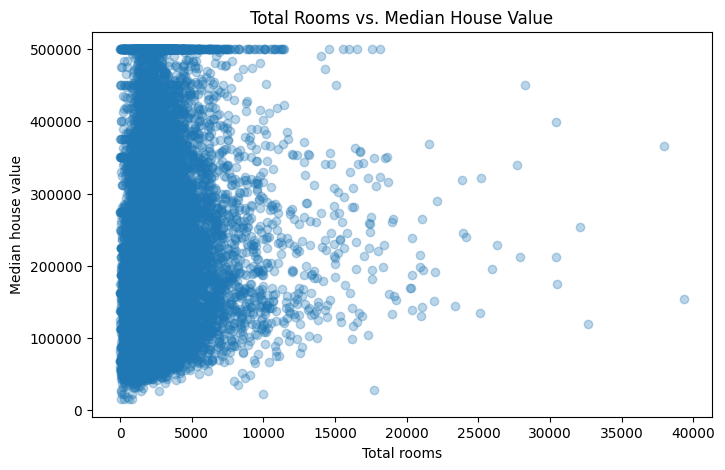

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(housing_data["total_rooms"], housing_data["median_house_value"], alpha=0.3)
plt.title("Total Rooms vs. Median House Value")
plt.xlabel("Total rooms")
plt.ylabel("Median house value")
plt.show()

## Correlation table

Correlation measures how strongly two numeric columns move together. Values closer to 1 or -1 show a stronger relationship.

In [10]:
numeric_columns = housing_data.select_dtypes(include="number")
correlation_with_price = numeric_columns.corr()["median_house_value"].sort_values(ascending=False)
correlation_with_price

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

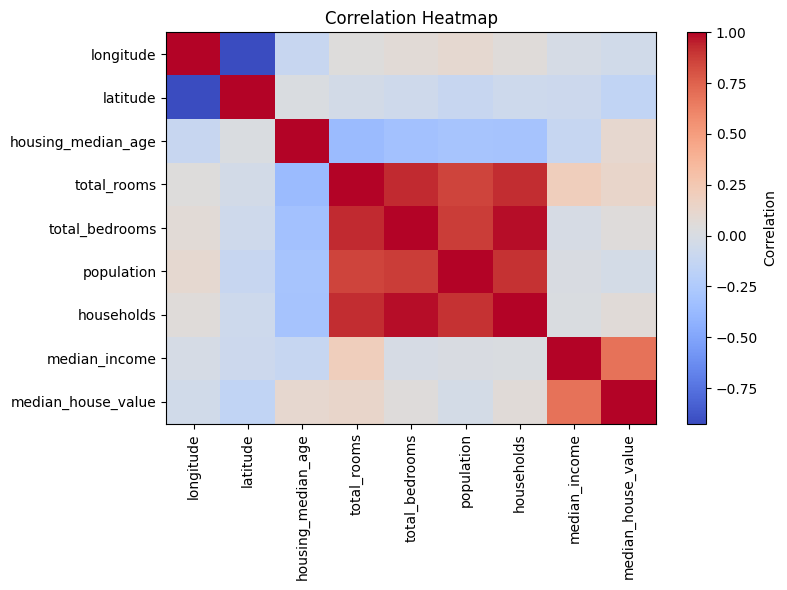

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(numeric_columns.corr(), cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_columns.columns)), numeric_columns.columns, rotation=90)
plt.yticks(range(len(numeric_columns.columns)), numeric_columns.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Summary

Write your observations here after running the notebook. For example:

- Which columns have missing values?
- Which features seem most related to `median_house_value`?
- Does the price distribution look evenly spread out, or are many values grouped together?